# Phase 1: Environment Setup and Data Loading. Load the Leo Telecom churn CSV, verify its expected schema, and inspect data quality. Place the approved source file at `data/raw/customer_churn.csv`.

## Setup and Locate the Dataset. Import Pandas and discover the project folder from the current working directory.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def find_project_root(start_path=None):
    current_path = Path(start_path or Path.cwd()).resolve()
    for candidate in (current_path, *current_path.parents):
        if (candidate / "README.md").is_file() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current path.")


def require_columns(dataframe, required_columns, phase_name):
    missing_columns = sorted(set(required_columns).difference(dataframe.columns))
    if missing_columns:
        raise ValueError(
            f"{phase_name} requires missing columns: {', '.join(missing_columns)}"
        )


project_root = find_project_root()
dataset_path = project_root / "data" / "raw" / "customer_churn.csv"
print(f"Project folder: {project_root}")
print(f"Dataset path:  {dataset_path}")

Project folder: D:\work_dsi\Work\My Growth\STEP UP\GenericUtilities\GenAI_Intellipaat\Customer_Churn_Prediction
Dataset path:  D:\work_dsi\Work\My Growth\STEP UP\GenericUtilities\GenAI_Intellipaat\Customer_Churn_Prediction\data\raw\customer_churn.csv


## Load the CSV. If the source data is absent, show the expected location without generating substitute records.

In [33]:
def load_customer_csv(file_path):
    if not file_path.is_file():
        print(f"Dataset not found. Add customer_churn.csv to {file_path.parent}.")
        return None

    dataframe = pd.read_csv(file_path, low_memory=False)
    print(f"Loaded {len(dataframe):,} customer records.")
    return dataframe


customer_churn = load_customer_csv(dataset_path)

Loaded 205 customer records.


## Inspect Structure and Data Quality\n\nCheck required fields, preview the data, inspect dtypes and nulls, and parse `TotalCharges` as numeric. The source CSV on disk is never changed.

In [34]:
def inspect_customer_data(dataframe):
    if dataframe is None:
        return None

    required_columns = {
        "gender",
        "SeniorCitizen",
        "InternetService",
        "PaymentMethod",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Churn",
    }
    require_columns(dataframe, required_columns, "Phase 1")
    inspected_data = dataframe.copy()

    print(
        f"Shape: {inspected_data.shape[0]:,} rows x "
        f"{inspected_data.shape[1]:,} columns"
    )
    print("\nFirst five records:")
    print(inspected_data.head().to_string(index=False))
    print("\nColumn and type summary:")
    inspected_data.info()

    total_charges_text = inspected_data["TotalCharges"].astype("string").str.strip()
    blank_total_charges = total_charges_text.eq("").fillna(False)
    parsed_total_charges = pd.to_numeric(
        total_charges_text.mask(blank_total_charges), errors="coerce"
    )
    invalid_total_charges = (
        total_charges_text.notna()
        & ~blank_total_charges
        & parsed_total_charges.isna()
    )
    inspected_data["TotalCharges"] = parsed_total_charges

    print("\nMissing values by column:")
    print(inspected_data.isna().sum().sort_values(ascending=False).to_string())
    print(f"\nBlank TotalCharges values converted to missing: {int(blank_total_charges.sum())}")
    print(f"Unparseable nonblank TotalCharges values: {int(invalid_total_charges.sum())}")
    print("\nNumeric field types:")
    numeric_columns = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
    print(inspected_data[numeric_columns].dtypes.to_string())
    return inspected_data


customer_churn = inspect_customer_data(customer_churn)

Shape: 205 rows x 21 columns

First five records:
customerID gender  SeniorCitizen Partner Dependents  tenure PhoneService    MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies       Contract PaperlessBilling             PaymentMethod  MonthlyCharges  TotalCharges  Churn
7590-VHVEG Female              0     Yes         No       1           No No phone service             DSL             No          Yes               No          No          No              No Month-to-month              Yes          Electronic check           29.85         29.85      0
5575-GNVDE   Male              0      No         No      34          Yes               No             DSL            Yes           No              Yes          No          No              No       One year               No              Mailed check           56.95       1889.50      0
3668-QPYBK   Male              0      No         No       2          Yes               No   

# Phase 2: Pandas Data Manipulation

Run this section after the Phase 1 data-loading and inspection cells. The subgroup DataFrames use distinct variable names so neither extraction overwrites the other.

In [35]:
def run_data_manipulation(dataframe):
    if dataframe is None:
        raise RuntimeError("Run Phase 1 before starting Phase 2.")

    required_columns = {
        "gender",
        "SeniorCitizen",
        "InternetService",
        "PaymentMethod",
        "tenure",
        "TotalCharges",
    }
    require_columns(dataframe, required_columns, "Phase 2")

    male_count = int(dataframe["gender"].eq("Male").sum())
    dsl_count = int(dataframe["InternetService"].eq("DSL").sum())
    senior_female_mailed = dataframe.loc[
        dataframe["gender"].eq("Female")
        & dataframe["SeniorCitizen"].eq(1)
        & dataframe["PaymentMethod"].eq("Mailed check")
    ].copy()
    short_tenure_or_low_charges = dataframe.loc[
        dataframe["tenure"].lt(10)
        | dataframe["TotalCharges"].lt(500).fillna(False)
    ].copy()

    print(f"Male customers: {male_count}")
    print(f"DSL customers: {dsl_count}")
    print(f"Female senior citizens paying by mailed check: {len(senior_female_mailed)}")
    print(
        "Customers with tenure < 10 or TotalCharges < 500: "
        f"{len(short_tenure_or_low_charges)}"
    )
    display(senior_female_mailed)
    display(short_tenure_or_low_charges)

    return {
        "male_count": male_count,
        "dsl_count": dsl_count,
        "senior_female_mailed": senior_female_mailed,
        "short_tenure_or_low_charges": short_tenure_or_low_charges,
    }


phase_2_results = run_data_manipulation(customer_churn)

Male customers: 112
DSL customers: 84
Female senior citizens paying by mailed check: 6
Customers with tenure < 10 or TotalCharges < 500: 42


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
8,SYNTH-000004,Female,1,Yes,No,52,Yes,No,Fiber optic,Yes,...,Yes,Yes,No,No,One year,No,Mailed check,102.32,5320.64,0
15,SYNTH-000011,Female,1,Yes,Yes,2,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,67.88,135.76,1
39,SYNTH-000035,Female,1,Yes,Yes,2,Yes,No,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Mailed check,35.87,71.74,1
49,SYNTH-000045,Female,1,Yes,Yes,16,Yes,No,DSL,No,...,No,Yes,No,Yes,Month-to-month,Yes,Mailed check,69.91,1118.56,1
111,SYNTH-000107,Female,1,Yes,No,2,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Month-to-month,No,Mailed check,63.91,127.82,1
129,SYNTH-000125,Female,1,No,No,8,Yes,Yes,DSL,No,...,No,No,Yes,Yes,One year,No,Mailed check,35.42,283.36,1


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
7,SYNTH-000003,Female,0,Yes,No,10,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),24.17,241.7,1
9,SYNTH-000005,Male,1,Yes,No,8,Yes,No,DSL,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),51.66,413.28,1
11,SYNTH-000007,Male,0,No,No,6,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,Month-to-month,No,Bank transfer (automatic),57.93,347.58,1
13,SYNTH-000009,Male,0,Yes,Yes,4,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,No,Two year,Yes,Mailed check,71.88,287.52,1
15,SYNTH-000011,Female,1,Yes,Yes,2,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,67.88,135.76,1
27,SYNTH-000023,Female,0,No,Yes,14,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),33.73,472.22,1
33,SYNTH-000029,Female,1,Yes,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,No,Month-to-month,No,Credit card (automatic),71.64,573.12,1


# Phase 3: Data Visualization

These charts use the 205-row synthetic demo dataset to demonstrate the plotting workflow. They are not representative of Leo Telecom's customer population; replace the demo CSV with approved data before interpreting the charts.

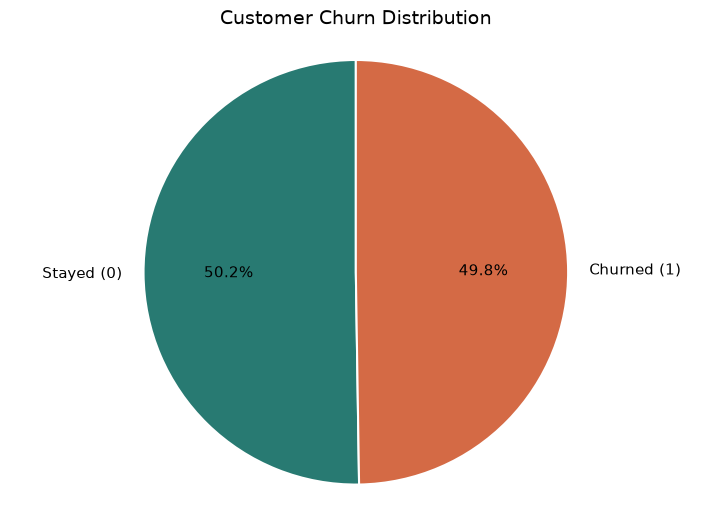

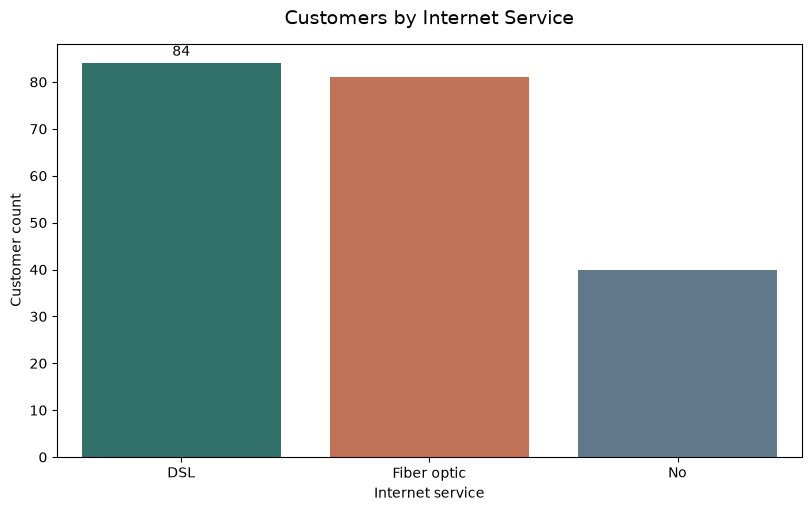

Churn counts:
Churn
Stayed     103
Churned    102

Internet-service counts:
InternetService
DSL            84
Fiber optic    81
No             40


In [36]:
def plot_churn_distribution(dataframe):
    if dataframe is None:
        raise RuntimeError("Run Phase 1 before plotting churn distribution.")
    require_columns(dataframe, {"Churn"}, "Phase 3 churn chart")

    churn_values = pd.to_numeric(dataframe["Churn"], errors="raise")
    observed_values = set(churn_values.dropna().unique())
    if not observed_values.issubset({0, 1}):
        raise ValueError(
            "Churn must contain only 0 (stayed) and 1 (churned) for plotting."
        )

    counts = churn_values.value_counts().reindex([0, 1], fill_value=0)
    labels = ["Stayed (0)", "Churned (1)"]
    colors = ["#287A72", "#D46A45"]
    figure, axis = plt.subplots(figsize=(7, 5), constrained_layout=True)
    axis.pie(
        counts.to_numpy(),
        labels=labels,
        colors=colors,
        autopct=lambda value: f"{value:.1f}%" if value else "",
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},
        textprops={"fontsize": 11},
    )
    axis.set_title("Customer Churn Distribution", fontsize=14, pad=14)
    axis.axis("equal")
    plt.show()
    return counts


def plot_internet_service_counts(dataframe):
    if dataframe is None:
        raise RuntimeError("Run Phase 1 before plotting internet-service counts.")
    require_columns(dataframe, {"InternetService"}, "Phase 3 internet-service chart")

    categories = ["DSL", "Fiber optic", "No"]
    observed_categories = set(dataframe["InternetService"].dropna().unique())
    unexpected_categories = sorted(observed_categories.difference(categories))
    if unexpected_categories:
        raise ValueError(
            "Unexpected InternetService categories: "
            f"{unexpected_categories}. Expected DSL, Fiber optic, or No."
        )

    counts = dataframe["InternetService"].value_counts().reindex(categories, fill_value=0)
    palette = {"DSL": "#287A72", "Fiber optic": "#D46A45", "No": "#5B7892"}
    figure, axis = plt.subplots(figsize=(8, 5), constrained_layout=True)
    sns.barplot(
        x=counts.index,
        y=counts.to_numpy(),
        hue=counts.index,
        palette=palette,
        legend=False,
        ax=axis,
    )
    axis.set_title("Customers by Internet Service", fontsize=14, pad=14)
    axis.set_xlabel("Internet service")
    axis.set_ylabel("Customer count")
    axis.set_ylim(bottom=0)
    axis.bar_label(axis.containers[0], padding=3, fmt="%d")
    plt.show()
    return counts


churn_counts = plot_churn_distribution(customer_churn)
internet_counts = plot_internet_service_counts(customer_churn)
print("Churn counts:")
print(churn_counts.rename(index={0: "Stayed", 1: "Churned"}).to_string())
print("\nInternet-service counts:")
print(internet_counts.to_string())

# Phase 4: Churn Model Building

Prepare one shared stratified 80/20 split, then fit a `tenure` baseline, a `tenure` model with dropout, and a three-feature model. The current 205-row file includes synthetic demo records so the fitting path can run; any resulting metrics are only workflow checks, not business findings.

In [37]:
import math


def prepare_model_data(dataframe, test_size=0.2, random_state=42):
    if dataframe is None:
        raise RuntimeError("Run Phase 1 before starting Phase 4.")

    feature_columns = ["tenure", "MonthlyCharges", "TotalCharges"]
    target_column = "Churn"
    require_columns(dataframe, set(feature_columns + [target_column]), "Phase 4")

    numeric_features = dataframe[feature_columns].apply(pd.to_numeric, errors="raise")
    raw_target = dataframe[target_column]
    numeric_target = pd.to_numeric(raw_target, errors="coerce")
    text_target = raw_target.astype("string").str.strip().str.casefold()
    text_encoding = text_target.map({"no": 0, "yes": 1})
    encoded_target = numeric_target.where(numeric_target.isin([0, 1]), text_encoding)
    invalid_target = raw_target.notna() & ~encoded_target.isin([0, 1])
    if invalid_target.any():
        values = sorted(raw_target.loc[invalid_target].astype(str).unique().tolist())
        raise ValueError(f"Churn must be binary (0/1 or No/Yes); found {values}.")

    model_data = numeric_features.copy()
    model_data[target_column] = encoded_target
    complete_rows = model_data.notna().all(axis=1)
    model_data = model_data.loc[complete_rows].copy()
    model_data[target_column] = model_data[target_column].astype(int)

    class_counts = model_data[target_column].value_counts().reindex([0, 1], fill_value=0)
    test_row_count = math.ceil(len(model_data) * test_size)
    train_row_count = len(model_data) - test_row_count
    split_ready = (
        class_counts.min() >= 2
        and test_row_count >= 2
        and train_row_count >= 2
    )

    print(f"Complete rows available for modeling: {len(model_data)}")
    print(f"Rows removed for missing model fields: {int((~complete_rows).sum())}")
    print(f"Churn class counts after encoding: {class_counts.to_dict()}")
    print(f"Planned split sizes: train={train_row_count}, test={test_row_count}")

    if not split_ready:
        print(
            "Model fitting skipped: a stratified split needs at least two rows "
            "per class and at least two rows in each partition."
        )
        return model_data, [], [], False

    from sklearn.model_selection import train_test_split

    train_indices, test_indices = train_test_split(
        model_data.index,
        test_size=test_size,
        random_state=random_state,
        stratify=model_data[target_column],
    )
    print("Shared stratified split is ready for all three models.")
    return model_data, train_indices, test_indices, True


model_data, train_indices, test_indices, model_split_ready = prepare_model_data(
    customer_churn
)

Complete rows available for modeling: 205
Rows removed for missing model fields: 0
Churn class counts after encoding: {0: 103, 1: 102}
Planned split sizes: train=164, test=41
Shared stratified split is ready for all three models.


Tenure baseline test accuracy: 0.951
Tenure with dropout test accuracy: 0.951
Three numerical features test accuracy: 0.854


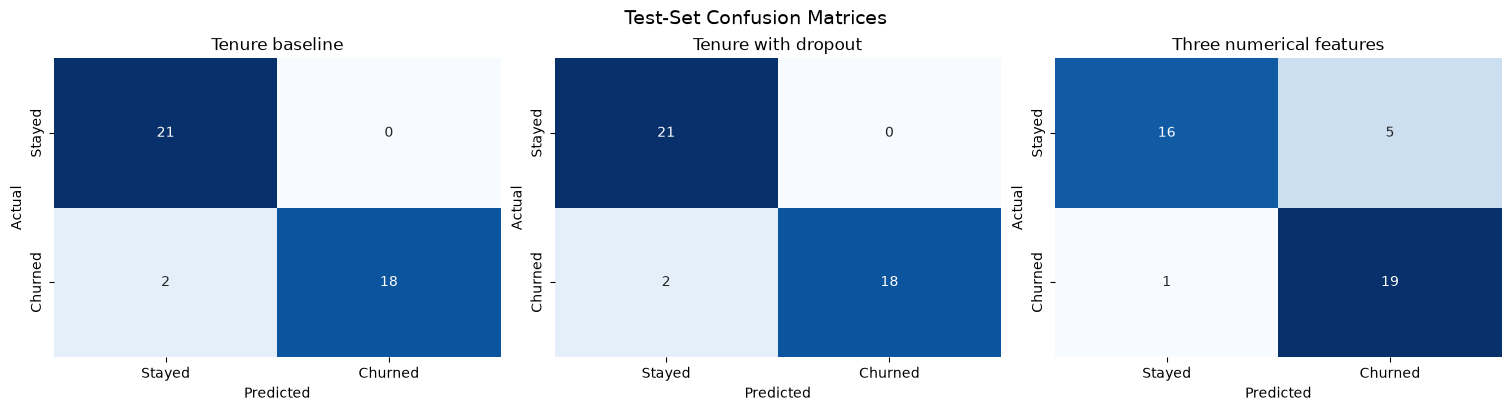

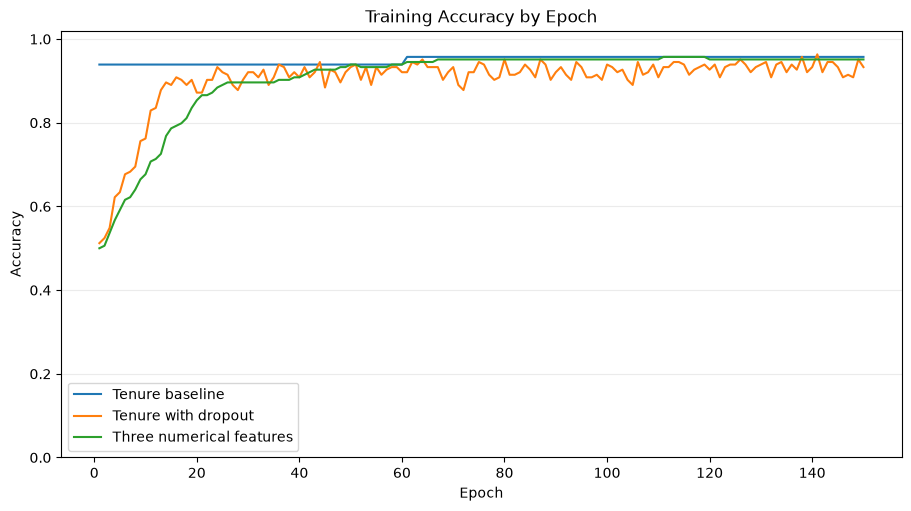

In [38]:
MODEL_SPECS = {
    "Tenure baseline": {"features": ["tenure"], "dropout": False},
    "Tenure with dropout": {"features": ["tenure"], "dropout": True},
    "Three numerical features": {
        "features": ["tenure", "MonthlyCharges", "TotalCharges"],
        "dropout": False,
    },
}


def build_churn_model(tf, input_feature_count, use_dropout, model_name):
    layers = [
        tf.keras.layers.Input(shape=(input_feature_count,)),
        tf.keras.layers.Dense(12, activation="relu"),
    ]
    if use_dropout:
        layers.append(tf.keras.layers.Dropout(0.3))
    layers.append(tf.keras.layers.Dense(8, activation="relu"))
    if use_dropout:
        layers.append(tf.keras.layers.Dropout(0.2))
    layers.append(tf.keras.layers.Dense(1, activation="sigmoid"))

    model = tf.keras.Sequential(layers, name=model_name.replace(" ", "_"))
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def plot_confusion_matrices(model_results):
    figure, axes = plt.subplots(
        1,
        len(model_results),
        figsize=(5 * len(model_results), 4),
        squeeze=False,
        constrained_layout=True,
    )
    for axis, (model_name, result) in zip(axes[0], model_results.items()):
        sns.heatmap(
            result["confusion_matrix"],
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=["Stayed", "Churned"],
            yticklabels=["Stayed", "Churned"],
            ax=axis,
        )
        axis.set_title(model_name)
        axis.set_xlabel("Predicted")
        axis.set_ylabel("Actual")
    figure.suptitle("Test-Set Confusion Matrices", fontsize=14)
    plt.show()


def plot_training_accuracy(model_results):
    figure, axis = plt.subplots(figsize=(9, 5), constrained_layout=True)
    for model_name, result in model_results.items():
        accuracy_by_epoch = result["history"].history["accuracy"]
        axis.plot(
            range(1, len(accuracy_by_epoch) + 1),
            accuracy_by_epoch,
            label=model_name,
        )
    axis.set_title("Training Accuracy by Epoch")
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Accuracy")
    axis.set_ylim(0, 1.02)
    axis.legend()
    axis.grid(axis="y", alpha=0.25)
    plt.show()


def train_churn_models(dataframe, train_indices, test_indices, split_ready):
    if not split_ready:
        print("No models were trained because the dataset cannot support evaluation.")
        return {}

    try:
        import tensorflow as tf
    except ImportError as error:
        raise ImportError(
            "TensorFlow is required for Phase 4. Install project dependencies "
            "in this notebook's Python environment, then rerun this cell."
        ) from error

    from sklearn.metrics import accuracy_score, confusion_matrix
    from sklearn.preprocessing import StandardScaler

    tf.keras.utils.set_random_seed(42)
    results = {}
    for model_name, specification in MODEL_SPECS.items():
        feature_names = specification["features"]
        scaler = StandardScaler()
        x_train = scaler.fit_transform(dataframe.loc[train_indices, feature_names])
        x_test = scaler.transform(dataframe.loc[test_indices, feature_names])
        y_train = dataframe.loc[train_indices, "Churn"].to_numpy()
        y_test = dataframe.loc[test_indices, "Churn"].to_numpy()

        model = build_churn_model(
            tf,
            input_feature_count=len(feature_names),
            use_dropout=specification["dropout"],
            model_name=model_name,
        )
        history = model.fit(
            x_train,
            y_train,
            epochs=150,
            batch_size=min(32, len(y_train)),
            verbose=0,
        )
        probabilities = model(x_test, training=False).numpy().ravel()
        predictions = (probabilities >= 0.5).astype(int)
        matrix = confusion_matrix(y_test, predictions, labels=[0, 1])

        results[model_name] = {
            "features": feature_names,
            "model": model,
            "scaler": scaler,
            "history": history,
            "y_true": y_test,
            "y_pred": predictions,
            "confusion_matrix": matrix,
            "accuracy": accuracy_score(y_test, predictions),
        }
        print(f"{model_name} test accuracy: {results[model_name]['accuracy']:.3f}")

    plot_confusion_matrices(results)
    plot_training_accuracy(results)
    return results


model_results = train_churn_models(
    model_data,
    train_indices,
    test_indices,
    model_split_ready,
)

# Phase 5: Evaluation and Recommendations

Compare accuracy, churn precision, recall, and F1 from the shared test set. Any results produced from this synthetic demo dataset validate the workflow only and must not be interpreted as Leo Telecom findings.

In [40]:
EXPECTED_MODEL_NAMES = list(MODEL_SPECS)


def calculate_churn_metrics(confusion_matrix_value):
    _, false_positives, false_negatives, true_positives = confusion_matrix_value.ravel()
    precision = (
        true_positives / (true_positives + false_positives)
        if true_positives + false_positives
        else 0.0
    )
    recall = (
        true_positives / (true_positives + false_negatives)
        if true_positives + false_negatives
        else 0.0
    )
    f1_score = (
        2 * precision * recall / (precision + recall)
        if precision + recall
        else 0.0
    )
    return precision, recall, f1_score


def summarize_model_results(model_results, dataframe):
    if not model_results:
        print(
            "Evaluation is pending because Phase 4 did not train models. "
            "Check dataset size and the notebook's ML dependencies."
        )
        return pd.DataFrame(
            columns=["accuracy", "churn_precision", "churn_recall", "churn_f1"]
        )

    missing_models = sorted(set(EXPECTED_MODEL_NAMES).difference(model_results))
    if missing_models:
        raise ValueError(f"Missing Phase 4 model results: {', '.join(missing_models)}")

    comparison_rows = []
    for model_name in EXPECTED_MODEL_NAMES:
        result = model_results[model_name]
        precision, recall, f1_score = calculate_churn_metrics(
            result["confusion_matrix"]
        )
        comparison_rows.append(
            {
                "model": model_name,
                "accuracy": result["accuracy"],
                "churn_precision": precision,
                "churn_recall": recall,
                "churn_f1": f1_score,
            }
        )

    comparison = pd.DataFrame(comparison_rows).set_index("model")
    display(comparison.round(3))

    baseline_accuracy = comparison.loc["Tenure baseline", "accuracy"]
    dropout_change = comparison.loc["Tenure with dropout", "accuracy"] - baseline_accuracy
    feature_change = comparison.loc["Three numerical features", "accuracy"] - baseline_accuracy
    print(f"Dropout accuracy change vs. baseline: {dropout_change:+.3f}")
    print(f"Three-feature accuracy change vs. baseline: {feature_change:+.3f}")

    best_recall_model = comparison["churn_recall"].idxmax()
    print(
        f"Highest test churn recall: {best_recall_model} "
        f"({comparison.loc[best_recall_model, 'churn_recall']:.3f})."
    )
    print(
        "Treat this model as a validation candidate, not an automatic retention "
        "decision. Review precision, intervention capacity, costs, and later-period "
        "performance before deployment."
    )

    customer_ids = dataframe.get(
        "customerID", pd.Series("", index=dataframe.index, dtype="string")
    ).astype("string")
    synthetic_rows_present = customer_ids.str.startswith("SYNTH-").any()
    if synthetic_rows_present:
        print(
            "Synthetic demo rows are present; this comparison validates the "
            "pipeline only and is not evidence about Leo Telecom customers."
        )
    return comparison


phase_5_comparison = summarize_model_results(model_results, customer_churn)

,accuracy,churn_precision,churn_recall,churn_f1
model,,,,
Tenure baseline,0.951,1.000,0.90,0.947
Tenure with dropout,0.951,1.000,0.90,0.947
Three numerical features,0.854,0.792,0.95,0.864


Dropout accuracy change vs. baseline: +0.000
Three-feature accuracy change vs. baseline: -0.098
Highest test churn recall: Three numerical features (0.950).
Treat this model as a validation candidate, not an automatic retention decision. Review precision, intervention capacity, costs, and later-period performance before deployment.
Synthetic demo rows are present; this comparison validates the pipeline only and is not evidence about Leo Telecom customers.
